<a href="https://colab.research.google.com/github/ChanZH0525/Salary-Prediction-Prototype-Model/blob/main/Malaysia_Jobstreet_Salary_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("hf://datasets/azrai99/job-dataset/jobstreet_all_job_dataset.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [2]:
def quick_eda(df):
    print("="*50)
    print("BASIC INFO")
    print(f"Shape: {df.shape}")
    print(f"\nColumns:\n{df.dtypes}")

    print("\n" + "="*50)
    print("MISSING (%):")
    print(df.isnull().sum() / len(df) * 100)

    print("\n" + "="*50)
    print("UNIQUE VALUES:")
    for col in ['type', 'category', 'location']:
        if col in df.columns:
            print(f"{col}: {df[col].nunique()}")

    print("\n" + "="*50)
    print("SALARY SAMPLE (first 10 non-null):")
    salary_sample = df['salary'].dropna().head(10)
    for s in salary_sample:
        print(f"  {s}")

    print("\n" + "="*50)
    print("DATE RANGE (if listingDate exists):")
    if 'listingDate' in df.columns:
        df['listingDate_parsed'] = pd.to_datetime(df['listingDate'], errors='coerce')
        print(f"  Min: {df['listingDate_parsed'].min()}")
        print(f"  Max: {df['listingDate_parsed'].max()}")

quick_eda(df)

BASIC INFO
Shape: (59306, 11)

Columns:
job_id           int64
job_title       object
company         object
descriptions    object
location        object
category        object
subcategory     object
role            object
type            object
salary          object
listingDate     object
dtype: object

MISSING (%):
job_id           0.000000
job_title        0.000000
company          0.000000
descriptions     0.000000
location         0.000000
category         0.000000
subcategory      0.000000
role             3.264425
type             0.000000
salary          55.078744
listingDate      0.000000
dtype: float64

UNIQUE VALUES:
type: 4
category: 30
location: 204

SALARY SAMPLE (first 10 non-null):
  RM 2,800 – RM 3,200 per month
  RM 3,000 – RM 3,500 per month
  RM 2,800 – RM 3,500 per month
  RM 3,000 – RM 4,500 per month
  RM 2,000 – RM 3,000 per month
  RM 3,000 – RM 3,200 per month
  RM 1,600 – RM 2,000 per month
  RM 3,500 – RM 4,000 per month
  RM 3,000 – RM 4,000 per month
  R

In [3]:
import re
import pandas as pd

def parse_salary(salary_str):
    """Convert Malaysian salary string to annualized MYR."""
    if pd.isna(salary_str) or salary_str == "":
        return None

    # Extract all numbers from string, ensuring they start with a digit
    numbers = re.findall(r'\d[\d,]*', salary_str)
    if not numbers:
        return None

    # Clean numbers (remove commas, convert to int)
    numbers = [int(n.replace(',', '')) for n in numbers]

    # Get the average if range, else single value
    salary = sum(numbers) / len(numbers) if len(numbers) > 1 else numbers[0]

    # Convert to annual (detect period)
    if 'per month' in salary_str.lower() or 'month' in salary_str.lower():
        salary *= 12
    # If no period mentioned, assume monthly (common in this dataset)
    elif 'per year' not in salary_str.lower():
        salary *= 12

    return salary

# Apply to full dataset
df['salary_annualized'] = df['salary'].apply(parse_salary)

In [4]:
print(f"Parsed successfully: {df['salary_annualized'].notna().sum()}")
print(f"Still missing: {df['salary_annualized'].isna().sum()}")
print(f"Salary range: {df['salary_annualized'].min():.0f} - {df['salary_annualized'].max():.0f}")

Parsed successfully: 26567
Still missing: 32739
Salary range: 12 - 3000000


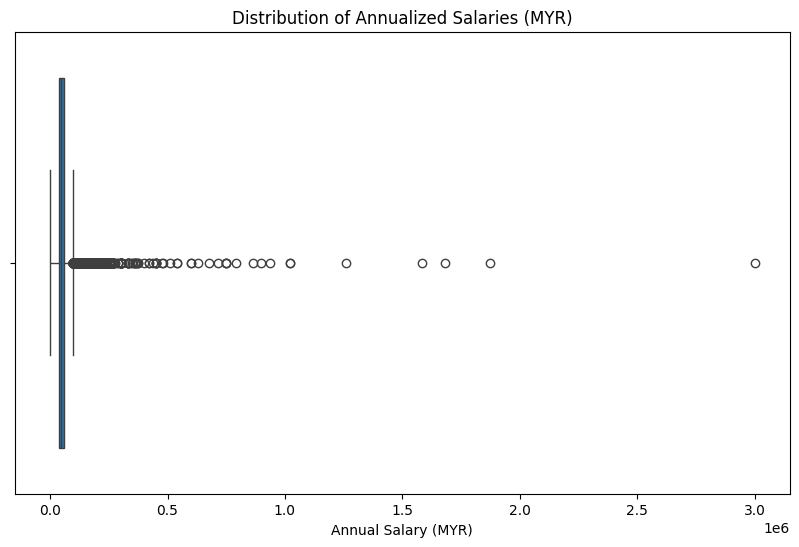

count    2.656700e+04
mean     5.444665e+04
std      4.613999e+04
min      1.200000e+01
1%       6.600000e+03
5%       2.100000e+04
25%      3.600000e+04
50%      4.500000e+04
75%      6.000000e+04
95%      1.170000e+05
99%      1.920000e+05
max      3.000000e+06
Name: salary_annualized, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to parsed salaries only
parsed_salaries = df[df['salary_annualized'].notna()]['salary_annualized']

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=parsed_salaries)
plt.title('Distribution of Annualized Salaries (MYR)')
plt.xlabel('Annual Salary (MYR)')
plt.show()

# Also print percentiles
print(parsed_salaries.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

In [6]:
# Calculate bounds from the parsed salaries
lower = parsed_salaries.quantile(0.01)
upper = parsed_salaries.quantile(0.99)

print(f"Keeping salaries between: RM{lower:.0f} - RM{upper:.0f}")

# Apply clipping
df['salary_clean'] = df['salary_annualized'].apply(
    lambda x: x if pd.isna(x) or (lower <= x <= upper) else None
)

print(f"After clipping: {df['salary_clean'].notna().sum()} salaries retained")
print(f"Range: {df['salary_clean'].min():.0f} - {df['salary_clean'].max():.0f}")

Keeping salaries between: RM6600 - RM192000
After clipping: 26045 salaries retained
Range: 6600 - 192000


MISSING RATE BY CATEGORY
                                        salary_missing  job_id
category                                                      
Government & Defence                              0.79      29
Banking & Financial Services                      0.75    2362
Consulting & Strategy                             0.75     270
Engineering                                       0.71    8092
Insurance & Superannuation                        0.71     178
CEO & General Management                          0.70      99
Information & Communication Technology            0.70    7872
Science & Technology                              0.64     476
Human Resources & Recruitment                     0.59    3714
Real Estate & Property                            0.57     582
Mining, Resources & Energy                        0.56      93
Community Services & Development                  0.55      33
Legal                                             0.54     315
Manufacturing, Transport & Log

/tmp/ipykernel_4792/3894598160.py:53: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['listingDate_parsed'].dt.to_period('M') # Use the parsed datetime column


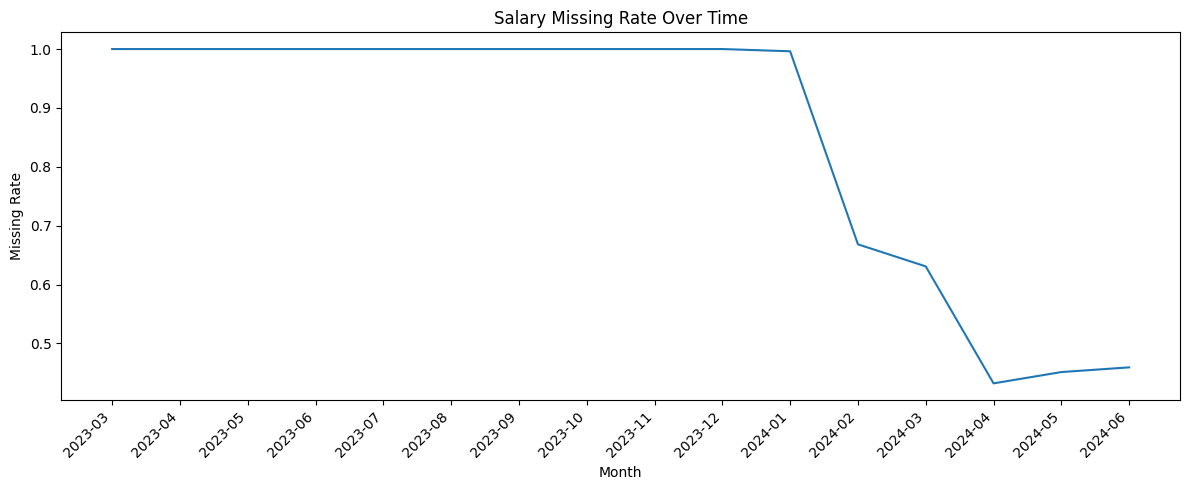


DESCRIPTION LENGTH COMPARISON
Missing salary - avg description length: 2046
Has salary - avg description length: 1632


In [7]:
# 1. Create missing flag
df['salary_missing'] = df['salary_clean'].isna()

# 2. Compare missing vs non-missing by category
missing_by_category = df.groupby('category').agg({
    'salary_missing': 'mean',
    'job_id': 'count'
}).round(2).sort_values('salary_missing', ascending=False)

print("="*60)
print("MISSING RATE BY CATEGORY")
print("="*60)
print(missing_by_category.head(20))

# 3. Compare job titles with highest missing rates
title_missing = df.groupby('job_title').agg({
    'salary_missing': 'mean',
    'job_id': 'count'
}).round(2)
title_missing = title_missing[title_missing['job_id'] >= 10].sort_values('salary_missing', ascending=False)

print("\n" + "="*60)
print("JOB TITLES WITH HIGHEST MISSING RATES (min 10 samples)")
print("="*60)
print(title_missing.head(15))

# 4. Check if missing rate correlates with job level (using title keywords)
def detect_job_level(title):
    title_lower = str(title).lower()
    if any(word in title_lower for word in ['intern', 'junior', 'entry', 'fresh']):
        return 'Entry'
    elif any(word in title_lower for word in ['senior', 'lead', 'principal', 'manager', 'director', 'vp', 'head']):
        return 'Senior'
    else:
        return 'Mid'

df['job_level'] = df['job_title'].apply(detect_job_level)
level_missing = df.groupby('job_level')['salary_missing'].mean()

print("\n" + "="*60)
print("MISSING RATE BY JOB LEVEL")
print("="*60)
print(level_missing)

# 5. Check by work type
type_missing = df.groupby('type')['salary_missing'].mean()
print("\n" + "="*60)
print("MISSING RATE BY WORK TYPE")
print("="*60)
print(type_missing)

# 6. Check temporal trend (if missing rate changed over time)
df['month'] = df['listingDate_parsed'].dt.to_period('M') # Use the parsed datetime column
temporal_missing = df.groupby('month')['salary_missing'].mean()

plt.figure(figsize=(12, 5))
plt.plot(temporal_missing.index.astype(str), temporal_missing.values)
plt.xticks(rotation=45, ha='right')
plt.title('Salary Missing Rate Over Time')
plt.xlabel('Month')
plt.ylabel('Missing Rate')
plt.tight_layout()
plt.show()

# 7. Compare text length between missing and non-missing
df['desc_length'] = df['descriptions'].str.len()
print("\n" + "="*60)
print("DESCRIPTION LENGTH COMPARISON")
print("="*60)
print(f"Missing salary - avg description length: {df[df['salary_missing']]['desc_length'].mean():.0f}")
print(f"Has salary - avg description length: {df[~df['salary_missing']]['desc_length'].mean():.0f}")

In [8]:
# Define job level detection function
def detect_job_level(title):
    title_lower = str(title).lower()
    if any(word in title_lower for word in ['intern', 'junior', 'entry', 'fresh', 'trainee']):
        return 'Entry'
    elif any(word in title_lower for word in ['senior', 'lead', 'principal', 'manager', 'director', 'vp', 'head', 'chief']):
        return 'Senior'
    else:
        return 'Mid'

# Apply to all splits (but only use train to create imputation map)
# First, re-run your split to get clean train/val/test with original data
# Then add job_level to each split

In [9]:
# Sort by date first
df = df.sort_values('listingDate').reset_index(drop=True)

# Calculate split indices
train_end = int(0.8 * len(df))
val_end = int(0.9 * len(df))

# Split
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

# Verify
print(f"Train: {len(train_df)} rows, {train_df['listingDate'].min()} to {train_df['listingDate'].max()}")
print(f"Val: {len(val_df)} rows, {val_df['listingDate'].min()} to {val_df['listingDate'].max()}")
print(f"Test: {len(test_df)} rows, {test_df['listingDate'].min()} to {test_df['listingDate'].max()}")

# Check salary coverage in each split
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    has_salary = split['salary_clean'].notna().sum()
    print(f"{name} salary coverage: {has_salary}/{len(split)} ({has_salary/len(split)*100:.1f}%)")

Train: 47444 rows, 2023-03-23T19:44:00Z to 2024-05-17T03:57:56Z
Val: 5931 rows, 2024-05-17T03:58:48Z to 2024-06-06T04:00:44Z
Test: 5931 rows, 2024-06-06T04:02:47Z to 2024-06-19T18:40:32Z
Train salary coverage: 19656/47444 (41.4%)
Val salary coverage: 3219/5931 (54.3%)
Test salary coverage: 3170/5931 (53.4%)


In [10]:
# Add job_level to existing splits
train_df['job_level'] = train_df['job_title'].apply(detect_job_level)
val_df['job_level'] = val_df['job_title'].apply(detect_job_level)
test_df['job_level'] = test_df['job_title'].apply(detect_job_level)

# Check distribution
print(train_df['job_level'].value_counts())

job_level
Mid       32687
Senior    11316
Entry      3441
Name: count, dtype: int64


In [11]:
def create_imputation_map_v2(train_df):
    """Create imputation with priority: (category, job_level) → category → global"""

    # Level 1: Exact match (category + job_level)
    level1 = train_df[train_df['salary_clean'].notna()].groupby(
        ['category', 'job_level']
    )['salary_clean'].median().to_dict()

    # Level 2: Category only (fallback)
    level2 = train_df[train_df['salary_clean'].notna()].groupby(
        'category'
    )['salary_clean'].median().to_dict()

    # Level 3: Global median
    level3 = train_df[train_df['salary_clean'].notna()]['salary_clean'].median()

    return level1, level2, level3

def impute_salary_v2(df, level1, level2, level3):
    """Apply imputation using category + job_level"""
    df = df.copy()

    def get_imputed(row):
        if pd.notna(row['salary_clean']):
            return row['salary_clean']

        # Try exact match (category + job_level)
        key = (row['category'], row['job_level'])
        if key in level1:
            return level1[key]

        # Try category only
        if row['category'] in level2:
            return level2[row['category']]

        # Fallback to global
        return level3

    df['salary_imputed'] = df.apply(get_imputed, axis=1)

    # Track imputation source
    def get_source(row):
        if pd.notna(row['salary_clean']):
            return 'original'
        key = (row['category'], row['job_level'])
        if key in level1:
            return 'category+level'
        if row['category'] in level2:
            return 'category_only'
        return 'global'

    df['salary_source'] = df.apply(get_source, axis=1)

    return df

# Create imputation map from TRAIN only
level1, level2, level3 = create_imputation_map_v2(train_df)

# Apply to all splits
train_df = impute_salary_v2(train_df, level1, level2, level3)
val_df = impute_salary_v2(val_df, level1, level2, level3)
test_df = impute_salary_v2(test_df, level1, level2, level3)

# Check coverage
print("\nImputation source breakdown (TRAIN):")
print(train_df['salary_source'].value_counts())


Imputation source breakdown (TRAIN):
salary_source
category+level    27780
original          19656
category_only         8
Name: count, dtype: int64


In [12]:
import numpy as np

# Apply log1p transformation
train_df['salary_log'] = np.log1p(train_df['salary_imputed'])
val_df['salary_log'] = np.log1p(val_df['salary_imputed'])
test_df['salary_log'] = np.log1p(test_df['salary_imputed'])

# Check distribution
print("Original salary (imputed):")
print(train_df['salary_imputed'].describe())

print("\nLog-transformed salary:")
print(train_df['salary_log'].describe())

Original salary (imputed):
count     47444.000000
mean      53215.846588
std       22564.222060
min        6600.000000
25%       40200.000000
50%       45000.000000
75%       60000.000000
max      192000.000000
Name: salary_imputed, dtype: float64

Log-transformed salary:
count    47444.000000
mean        10.799470
std          0.413172
min          8.794976
25%         10.601647
50%         10.714440
75%         11.002117
max         12.165256
Name: salary_log, dtype: float64


In [13]:
def build_structured_text(row):
    """Combine job features into structured text."""
    parts = [
        f"TITLE: {row['job_title']}",
        f"CATEGORY: {row['category']}",
        f"SUBCATEGORY: {row['subcategory']}",
        f"TYPE: {row['type']}",
        f"LOCATION: {row['location']}",
        f"DESCRIPTION: {row['descriptions']}"
    ]
    return " | ".join(parts)

# Apply to all splits
train_df['text'] = train_df.apply(build_structured_text, axis=1)
val_df['text'] = val_df.apply(build_structured_text, axis=1)
test_df['text'] = test_df.apply(build_structured_text, axis=1)

# Check example
print(train_df['text'].iloc[0][:500])

TITLE: Sales Executive (Full-Time) | CATEGORY: Sales | SUBCATEGORY: Account & Relationship Management | TYPE: Full time | LOCATION: Selangor | DESCRIPTION: Car maintenance and handphone provided
Minimum 2 years experience
Responsibilities
:
To expand current portfolio and develop new markets
To plan, execute and achieve sales strategies
To work closely with Sales and Marketing team to identify, potential leads by various communications tools and networking
To service bookshops to ensure continue


In [14]:
# Extract text and labels
train_texts = train_df['text'].tolist()
train_labels = train_df['salary_log'].tolist()

val_texts = val_df['text'].tolist()
val_labels = val_df['salary_log'].tolist()

test_texts = test_df['text'].tolist()
test_labels = test_df['salary_log'].tolist()

# Confirm shapes
print(f"Train: {len(train_texts)} samples")
print(f"Val: {len(val_texts)} samples")
print(f"Test: {len(test_texts)} samples")
print(f"\nLabel range: {min(train_labels):.2f} - {max(train_labels):.2f}")

Train: 47444 samples
Val: 5931 samples
Test: 5931 samples

Label range: 8.79 - 12.17


In [15]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Use DistilBERT for faster training (you can switch to JobBERT later)
model_name = "distilbert-base-uncased"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load model with regression head (num_labels=1 for single value prediction)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1,
    problem_type="regression"
)

# Check if GPU available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


In [16]:
from torch.utils.data import Dataset, DataLoader

class SalaryDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.float)
        }

# Create datasets
batch_size = 16

train_dataset = SalaryDataset(train_texts, train_labels, tokenizer)
val_dataset = SalaryDataset(val_texts, val_labels, tokenizer)
test_dataset = SalaryDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2966
Val batches: 371
Test batches: 371


In [17]:
from transformers import EarlyStoppingCallback
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.flatten()
    labels = labels.flatten()

    # Convert from log space back to original salary
    pred_salary = np.expm1(predictions)
    true_salary = np.expm1(labels)

    mae = mean_absolute_error(true_salary, pred_salary)
    rmse = np.sqrt(mean_squared_error(true_salary, pred_salary))
    r2 = r2_score(true_salary, pred_salary)

    # ±20K accuracy
    within_20k = np.abs(pred_salary - true_salary) <= 20000
    acc_20k = within_20k.mean()

    return {"mae": mae, "rmse": rmse, "r2": r2, "acc_20k": acc_20k}

# Training arguments with more epochs
training_args = TrainingArguments(
    output_dir='./salary_results',
    num_train_epochs=7,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_steps=250,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_mae',
    greater_is_better=False,
    fp16=True,
    save_total_limit=2,  # Keep only 2 best checkpoints
    dataloader_num_workers=4,
    remove_unused_columns=True,
    max_grad_norm=1.0,  # Clip gradients for stability
)

# Initialize trainer with early stopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# Train
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/f

Epoch,Training Loss,Validation Loss,Mae,Rmse,R2,Acc 20k
1,0.151478,0.073907,11022.992188,15751.593189,0.511742,0.868825
2,0.143242,0.071638,11278.571289,15851.548316,0.505526,0.853650
3,0.132247,0.074167,11494.871094,15583.384485,0.522114,0.870679
4,0.132218,0.069305,10941.647461,15147.409548,0.548480,0.879953
5,0.129453,0.073636,11674.534180,15532.813782,0.525211,0.863935
6,0.120539,0.064495,10365.839844,14554.948025,0.583110,0.896982
7,0.123779,0.057152,9362.172852,14006.254032,0.613949,0.901534


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=10381, training_loss=1.3756245834590175, metrics={'train_runtime': 4559.0141, 'train_samples_per_second': 72.846, 'train_steps_per_second': 2.277, 'total_flos': 4.39926982715351e+16, 'train_loss': 1.3756245834590175, 'epoch': 7.0})

In [19]:
# Load best model
# The trainer automatically loads the best model at the end of training
best_model = trainer.model
best_model.to(device)

# Create trainer with best model
test_trainer = Trainer(
    model=best_model,
    args=training_args,
    compute_metrics=compute_metrics,
    eval_dataset=test_dataset # Pass the test_dataset here
)

# Evaluate on test set
test_results = test_trainer.evaluate(eval_dataset=test_dataset)
print("\nTest Results:")
for key, value in test_results.items():
    if key.startswith('eval_'):
        print(f"{key}: {value:.2f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Test Results:
eval_loss: 0.06
eval_model_preparation_time: 0.00
eval_mae: 9272.79
eval_rmse: 13840.75
eval_r2: 0.61
eval_acc_20k: 0.91
eval_runtime: 27.75
eval_samples_per_second: 213.70
eval_steps_per_second: 6.70


In [20]:
# Save final model
best_model.save_pretrained('./salary_prediction_model')
tokenizer.save_pretrained('./salary_prediction_model')

print("Model saved to ./salary_prediction_model")

# Test inference on a single example
def predict_salary(job_posting_text):
    inputs = tokenizer(job_posting_text, return_tensors='pt', truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        log_pred = best_model(**inputs).logits.flatten().item()
    return np.expm1(log_pred)

# Test
sample = train_df['text'].iloc[0]
pred = predict_salary(sample)
actual = np.expm1(train_df['salary_log'].iloc[0])
print(f"Sample prediction: RM{pred:.0f}")
print(f"Actual: RM{actual:.0f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./salary_prediction_model
Sample prediction: RM55808
Actual: RM49800


/tmp/ipykernel_4792/945236306.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct_error_by_range = error_df.groupby('salary_range')['pct_error'].mean()


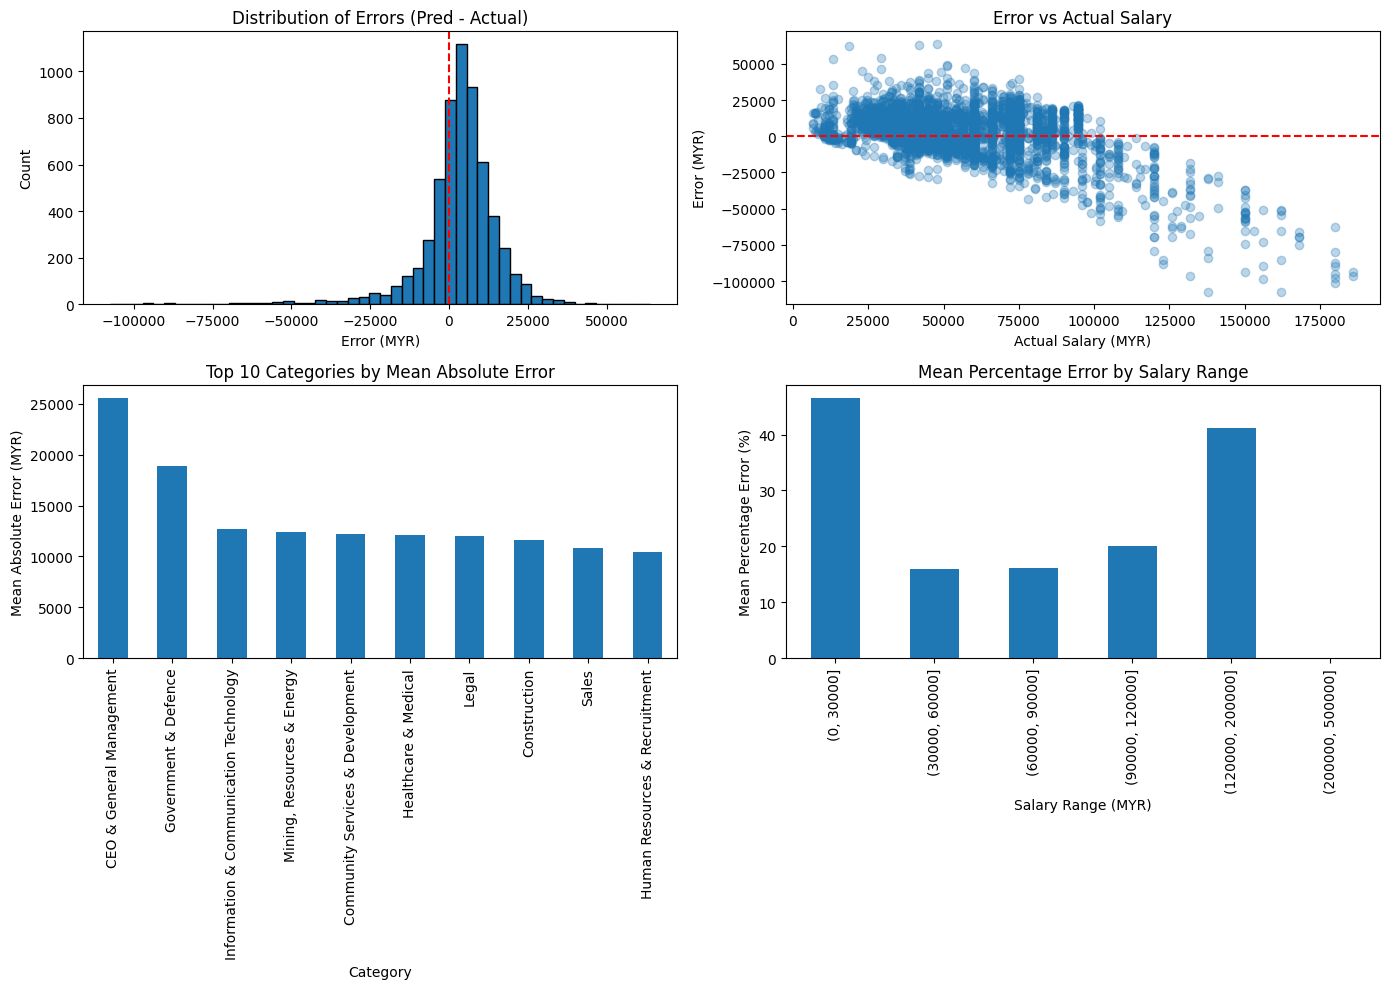


WORST 10 PREDICTIONS (highest absolute error)

Job: SAP Supply Chain Designer (Manufacturing, Transport & Logistics)
  Actual: RM162,000 | Predicted: RM54,515
  Error: RM-107,485

Job: Entry Level for Degree at Singapore : Management Trainee (Training provided) (Hospitality & Tourism)
  Actual: RM138,000 | Predicted: RM30,820
  Error: RM-107,180

Job: Java Engineer (Information & Communication Technology)
  Actual: RM180,000 | Predicted: RM78,702
  Error: RM-101,298

Job: Environmental, Health and Safety (EHS) Officer (Construction)
  Actual: RM156,000 | Predicted: RM57,579
  Error: RM-98,421

Job: Regional Marketing Manager (Southeast Asia) (Marketing & Communications)
  Actual: RM180,000 | Predicted: RM82,479
  Error: RM-97,521

Job: Cabin Crew - Based in Singapore Intake (Recruitment in KL) (Hospitality & Tourism)
  Actual: RM132,000 | Predicted: RM35,473
  Error: RM-96,527

Job: Sales Manager (Sales)
  Actual: RM186,000 | Predicted: RM89,881
  Error: RM-96,119

Job: General Manage

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Get predictions on test set
test_predictions = []
test_actuals = []

for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = best_model(**batch)
    preds = outputs.logits.flatten().cpu().numpy()
    labels = batch['labels'].cpu().numpy()

    test_predictions.extend(preds)
    test_actuals.extend(labels)

# Convert from log space
pred_salary = np.expm1(test_predictions)
actual_salary = np.expm1(test_actuals)
errors = pred_salary - actual_salary
abs_errors = np.abs(errors)

# Create error dataframe
error_df = test_df.copy()
error_df['pred_salary'] = pred_salary
error_df['actual_salary'] = actual_salary
error_df['error'] = errors
error_df['abs_error'] = abs_errors
error_df['pct_error'] = (abs_errors / actual_salary) * 100

# 1. Error distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of errors
axes[0, 0].hist(errors, bins=50, edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--')
axes[0, 0].set_title('Distribution of Errors (Pred - Actual)')
axes[0, 0].set_xlabel('Error (MYR)')
axes[0, 0].set_ylabel('Count')

# Error by actual salary
axes[0, 1].scatter(actual_salary, errors, alpha=0.3)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_title('Error vs Actual Salary')
axes[0, 1].set_xlabel('Actual Salary (MYR)')
axes[0, 1].set_ylabel('Error (MYR)')

# Absolute error by category
category_errors = error_df.groupby('category')['abs_error'].mean().sort_values(ascending=False).head(10)
category_errors.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Top 10 Categories by Mean Absolute Error')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Mean Absolute Error (MYR)')

# Percentage error by salary range
error_df['salary_range'] = pd.cut(actual_salary, bins=[0, 30000, 60000, 90000, 120000, 200000, 500000])
pct_error_by_range = error_df.groupby('salary_range')['pct_error'].mean()
pct_error_by_range.plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Mean Percentage Error by Salary Range')
axes[1, 1].set_xlabel('Salary Range (MYR)')
axes[1, 1].set_ylabel('Mean Percentage Error (%)')

plt.tight_layout()
plt.show()

# 2. Worst predictions
print("\n" + "="*50)
print("WORST 10 PREDICTIONS (highest absolute error)")
print("="*50)
worst = error_df.nlargest(10, 'abs_error')[['job_title', 'category', 'actual_salary', 'pred_salary', 'error', 'abs_error']]
for idx, row in worst.iterrows():
    print(f"\nJob: {row['job_title']} ({row['category']})")
    print(f"  Actual: RM{row['actual_salary']:,.0f} | Predicted: RM{row['pred_salary']:,.0f}")
    print(f"  Error: RM{row['error']:+,.0f}")

# 3. Best predictions
print("\n" + "="*50)
print("BEST 10 PREDICTIONS (lowest absolute error)")
print("="*50)
best = error_df.nsmallest(10, 'abs_error')[['job_title', 'category', 'actual_salary', 'pred_salary', 'error', 'abs_error']]
for idx, row in best.iterrows():
    print(f"\nJob: {row['job_title']} ({row['category']})")
    print(f"  Actual: RM{row['actual_salary']:,.0f} | Predicted: RM{row['pred_salary']:,.0f}")
    print(f"  Error: RM{row['error']:+,.0f}")

# 4. Summary statistics
print("\n" + "="*50)
print("ERROR SUMMARY BY CATEGORY")
print("="*50)
summary = error_df.groupby('category').agg({
    'abs_error': ['mean', 'median', 'std'],
    'pct_error': 'mean',
    'actual_salary': 'count'
}).round(0)
summary.columns = ['MAE', 'MAE_median', 'MAE_std', 'Avg_Pct_Error', 'Count']
summary = summary.sort_values('MAE', ascending=False)
print(summary.head(15))

# 5. Bias check (overpredict vs underpredict)
print("\n" + "="*50)
print("BIAS ANALYSIS")
print("="*50)
error_df['bias'] = error_df['error'].apply(lambda x: 'Overpredict' if x > 0 else ('Underpredict' if x < 0 else 'Perfect'))
bias_counts = error_df['bias'].value_counts()
print(bias_counts)
print(f"\nMean bias: RM{errors.mean():+.0f}")
print(f"Std bias: RM{errors.std():.0f}")